In [12]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import ascii
from astropy.table import Column
import pandas as pd
import matplotlib
from scipy.optimize import curve_fit
from astropy.time import Time
from PyAstronomy.pyasl import baryCorr
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.convolution import convolve, Box1DKernel
from matplotlib.gridspec import GridSpec


def init():
    matplotlib.rcParams['xtick.minor.size'] = 6
    matplotlib.rcParams['xtick.major.size'] = 8
    matplotlib.rcParams['ytick.major.size'] = 8
    matplotlib.rcParams['ytick.minor.size'] = 6
    matplotlib.rcParams['lines.linewidth'] = 1.0
    matplotlib.rcParams['axes.linewidth'] = 1.0
    matplotlib.rcParams['font.size']= 18
    matplotlib.rcParams['font.family']= 'sans-serif'
    matplotlib.rcParams['xtick.major.width']= 1.5
    matplotlib.rcParams['ytick.major.width']= 1.5
    matplotlib.rcParams['ytick.direction']='in'
    matplotlib.rcParams['xtick.direction']='in'

init()

In [13]:
class Spectrum:
    def __init__(self, wav_angstrom_uncorrected, flux, z=0, label=None, ra=None, dec=None, convert_to_vac=False):
        self.wav_angstrom_uncorrected = wav_angstrom_uncorrected
        self.flux = flux
        self.z = z
        self.wav_angstrom = wav_angstrom_uncorrected / (1 + z)
        if convert_to_vac:
            self.wav_angstrom *= 1.00027
        self.label = label
        self.jd = Time(label.split(': ')[-1]).jd
        self.ra = ra
        self.dec = dec
        self.vb, self.vh = None, None
        if self.ra is not None:
            vh, vb = baryCorr(self.jd, self.ra, self.dec, deq=2000.0)
            self.wav_angstrom = self.wav_angstrom / (1 - vb/3e5)
            self.vb = vb
            self.vh = vh


    def write_to_csv(self, directory):
        """
        Write the spectrum to a CSV file.
        :param directory: directory to save the CSV file
        :return:
        """
        df = pd.DataFrame({'wavelength': self.wav_angstrom, 'flux': self.flux})
        df.to_csv(f"{directory}/{self.label.replace(':', '').replace(' ', '_')}.csv", index=False)


    def continuum_normalize(self, degree, continuum_wavelengths:list[list], wavelength_min=None, wavelength_max=None):
        """
        Normalize the spectrum to the continuum using polynomial fitting.
        :param degree: degree of the polynomial to fit to the continuum
        :param continuum_wavelengths: e.g. [[4000, 4100], [4500, 4600]] the limits to use for continuum normalization
        :param wavelength_min: optional, minimum wavelength to consider for normalization
        :param wavelength_max: optional, maximum wavelength to consider for normalization
        :return:
        """
        if wavelength_min is None:
            wavelength_min = continuum_wavelengths[0][0]
        if wavelength_max is None:
            wavelength_max = continuum_wavelengths[1][1]

        # Filter the wavelengths and fluxes based on the provided limits
        mask = (self.wav_angstrom >= wavelength_min) & (self.wav_angstrom <= wavelength_max)
        wav_filtered = self.wav_angstrom[mask]
        flux_filtered = self.flux[mask]

        continuum_mask = ((wav_filtered > continuum_wavelengths[0][0]) & (wav_filtered < continuum_wavelengths[0][1])) | \
                            ((wav_filtered > continuum_wavelengths[1][0]) & (wav_filtered < continuum_wavelengths[1][1]))

        wav_continuum = wav_filtered[continuum_mask]
        flux_continuum = flux_filtered[continuum_mask]

        # Create a polynomial fit to the continuum

        coeffs = np.polyfit(wav_continuum, flux_continuum, degree)
        continuum_fit = np.polyval(coeffs, wav_filtered)

        # Normalize the flux by the fitted continuum
        flux_normalized = flux_filtered / continuum_fit

        return wav_filtered, flux_normalized, continuum_fit, wav_continuum, flux_continuum

    def fit_double_emission_absorption_gaussian(self, degree, continuum_wavelengths: list[list], central_wavelength, initial_guess,
                            wavelength_min=None, wavelength_max=None, bounds=None):
        """
        Function to fit a double gausssian : one emission component and one absorption component. The emission component is assumed to be positive and the absorption component is assumed to be negative.
        :return:
        """
        # First continuum normalize the spec, and work in velocity space
        wav_filtered, flux_normalized, continuum_fit, wav_continuum, flux_continuum = self.continuum_normalize(degree, continuum_wavelengths, wavelength_min, wavelength_max)
        flux_subtracted_normalized = flux_normalized - 1  # shift the normalized flux so that the continuum is at 0
        c = 299792.458  # speed of light in km/s
        velocity = (wav_filtered - central_wavelength) / central_wavelength * c
        # Fit the double gaussian to the normalized flux
        popt, pcov = curve_fit(double_gaussian, velocity, flux_subtracted_normalized, p0=initial_guess, bounds=bounds)
        return popt, pcov, velocity, flux_subtracted_normalized, continuum_fit, wav_continuum, flux_continuum

    def fit_single_emission_gaussian(self, degree, continuum_wavelengths: list[list], central_wavelength, initial_guess,
                            wavelength_min=None, wavelength_max=None, bounds=None):
        """
        Function to fit a double gausssian : one emission component and one absorption component. The emission component is assumed to be positive and the absorption component is assumed to be negative.
        :return:
        """
        # First continuum normalize the spec, and work in velocity space
        wav_filtered, flux_normalized, continuum_fit, wav_continuum, flux_continuum = self.continuum_normalize(degree, continuum_wavelengths, wavelength_min, wavelength_max)
        flux_subtracted_normalized = flux_normalized - 1  # shift the normalized flux so that the continuum is at 0
        c = 299792.458  # speed of light in km/s
        velocity = (wav_filtered - central_wavelength) / central_wavelength * c
        # Fit the double gaussian to the normalized flux
        popt, pcov = curve_fit(single_gaussian, velocity, flux_subtracted_normalized, p0=initial_guess, bounds=bounds)
        return popt, pcov, velocity, flux_subtracted_normalized, continuum_fit, wav_continuum, flux_continuum
    

    def bootstrap_velocity(self, mode, sn, degree, continuum_wavelengths, central_wavelength, initial_guess,
                           wavelength_min=None, wavelength_max=None, bounds=None, n_bootstrap=1000):
        """
        Bootstrap velocity uncertainty by resampling flux with Gaussian noise derived from a given S/N.

        mode         : 'single' or 'double' — selects which Gaussian model to fit
        sn           : per-pixel signal-to-noise ratio; flux uncertainty is computed as |flux| / sn
        n_bootstrap  : number of bootstrap iterations (default 1000)

        Returns a dict mapping parameter name -> (median, std) over successful fits:
          'single' mode : {'mu': (median_mu, std_mu)}
          'double' mode : {'mu_emission': (...), 'mu_absorption': (...)}
        """
        flux_err = np.abs(self.flux) / sn
        original_flux = self.flux.copy()

        popts = []
        for _ in range(n_bootstrap):
            self.flux = original_flux + np.random.normal(0, flux_err)
            try:
                if mode == 'single':
                    popt, *_ = self.fit_single_emission_gaussian(
                        degree, continuum_wavelengths, central_wavelength, initial_guess,
                        wavelength_min=wavelength_min, wavelength_max=wavelength_max, bounds=bounds)
                elif mode == 'double':
                    popt, *_ = self.fit_double_emission_absorption_gaussian(
                        degree, continuum_wavelengths, central_wavelength, initial_guess,
                        wavelength_min=wavelength_min, wavelength_max=wavelength_max, bounds=bounds)
                else:
                    raise ValueError(f"mode must be 'single' or 'double', got '{mode}'")
                popts.append(popt)
            except RuntimeError:
                pass
        self.flux = original_flux

        popts = np.array(popts)
        if mode == 'single':
            sigmas = popts[:, 2]
            return {'sigma': (np.median(sigmas), np.std(sigmas))}
        else:
            mus_em = popts[:, 2]
            mus_ab = popts[:, 5]
            return {
                'sigma_emission': (np.median(mus_em), np.std(mus_em)),
                'sigma_absorption': (np.median(mus_ab), np.std(mus_ab)),
            }

def double_gaussian(wav, A_emission, mu_emission, sigma_emission, A_absorption,
                    mu_absorption, sigma_absorption):
    return A_emission * np.exp(-(wav - mu_emission) ** 2 / (2 * sigma_emission ** 2)) + \
        A_absorption * np.exp(-(wav - mu_absorption) ** 2 / (2 * sigma_absorption ** 2))


def single_gaussian(wav, A_emission, mu_emission, sigma_emission):
    return A_emission * np.exp(-(wav - mu_emission) ** 2 / (2 * sigma_emission ** 2))


In [14]:
def load_spec(filename, wav_key='wav', flux_key='flam',
                     z=-0.00125, label=None, ra=None, dec=None, convert_vac=True, downsample=False, kernel_size=10):
    data = pd.read_csv(filename)
    fluxes = data[flux_key].values
    if downsample:
        box = Box1DKernel(kernel_size)
        convol_flx = convolve(data[flux_key].values, box)
        fluxes = convol_flx
    spec = Spectrum(
        wav_angstrom_uncorrected=data[wav_key].values,
        flux=fluxes,
        z=z,
        label=label,
        ra=ra,
        dec=dec,
        convert_to_vac=convert_vac
    )
    return spec

In [15]:
z = -0.0015
ra, dec = 9.702510,  40.768948


Dont forget to run the below cells to load the gmos and ngps files

In [49]:
bspec_251113 = load_spec( '../observational_data/spectra/2025-11-13T02:23:08_Binospec_48461.csv', label='Binospec : 2025-11-13', z=-0.0015, ra=ra, dec=dec, convert_vac=True)
ngps_251111 = load_spec( '../observational_data/spectra/2025-11-11T03:51:07_NGPS_48393.csv', label='NGPS : 2025-11-11', z=-0.0015, ra=ra, dec=dec)
ngps_251129 = load_spec( '../observational_data/spectra/2025-11-29T04:58:14_NGPS_48651.csv', label='NGPS : 2025-11-29', z=-0.0015, ra=ra, dec=dec)
ngps_251212 = load_spec( '../observational_data/spectra/2025-12-12T07:55:31_NGPS_49142.csv', label='NGPS : 2025-12-12', z=-0.0015, ra=ra, dec=dec)
ngps_251228 = load_spec( '../observational_data/spectra/2025-12-28T06:42:22_NGPS_49581.csv', label='NGPS : 2025-12-28', z=-0.0015, ra=ra, dec=dec) 
ngps_260126 = load_spec( '../observational_data/spectra/2026-01-26T03:33:42_NGPS_50088.csv', label='NGPS : 2026-01-26', z=-0.0015, ra=ra, dec=dec) 


In [17]:
gmos_251115_r = load_spec( '../observational_data/spectra/2025-11-15T00:00:00_GMOS.csv', label='GMOS (r): 2025-11-15', z=-0.0015, ra=ra, dec=dec) # red
gmos_251213_r = load_spec( '../observational_data/spectra/2025-12-13T05:58:33_GMOS_49283.csv', label='GMOS (r): 2025-12-13', z=-0.0015, ra=ra, dec=dec) #red
gmos_251224_r = load_spec( '../observational_data/spectra/2025-12-24T05:57:07_GMOS_49585.csv', label='GMOS (r): 2025-12-24', z=-0.0015, ra=ra, dec=dec) # red
gmos_260108_r = load_spec( '../observational_data/spectra/2026-01-08T06:57:36_GMOS_49727.csv', label='GMOS (r): 2026-01-08', z=-0.0015, ra=ra, dec=dec) #red
gmos_260126_r = load_spec( '../observational_data/spectra/2026-01-26T06:14:24_GMOS_50161.csv', label='GMOS (r): 2026-01-26', z=-0.0015, ra=ra, dec=dec) #red 
gmos_260206_r = load_spec( '../observational_data/spectra/2026-02-06T05:16:48_GMOS_50459.csv', label='GMOS (r): 2026-02-06', z=-0.0015, ra=ra, dec=dec) #red 

In [18]:
gmos_251122_b = load_spec( '../observational_data/spectra/2025-11-22T00:00:00_GMOS_49282.csv', label='GMOS (b): 2025-11-22', z=-0.0015, ra=ra, dec=dec) # blue
gmos_251217_b = load_spec( '../observational_data/spectra/2025-12-17T05:02:24_GMOS_49501.csv', label='GMOS (b): 2025-12-17', z=-0.0015, ra=ra, dec=dec) #blue
gmos_251225_b = load_spec( '../observational_data/spectra/2025-12-25T06:25:55_GMOS_49584.csv', label='GMOS (b): 2025-12-25', z=-0.0015, ra=ra, dec=dec) #blue
gmos_260107_b = load_spec( '../observational_data/spectra/2026-01-07T06:00:00_GMOS_49726.csv', label='GMOS (b): 2026-01-07', z=-0.0015, ra=ra, dec=dec) #blue
gmos_260205_b = load_spec( '../observational_data/spectra/2026-02-05T00:00:00_GMOS_50460.csv', label='GMOS (b): 2026-02-05', z=-0.0015, ra=ra, dec=dec) #blue 

[  0.52057569 -77.83478987 464.64847416]
[  0.64294917 -91.94841469 413.10099632]
[  0.56524253   4.28739436 350.5860365 ]
[  0.60574464 -83.69501829 328.7782539 ]
[ 2.52385722e-01 -4.91718622e+01  3.71171745e+02]
[ 2.94472089e-01 -1.24594645e+02  3.25586791e+02]


/Users/viraj/anaconda3/envs/wntr23bzdiq/lib/python3.11/site-packages/IPython/core/events.py:101: UserWarning: Glyph 65298 (\N{FULLWIDTH DIGIT TWO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/viraj/anaconda3/envs/wntr23bzdiq/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65298 (\N{FULLWIDTH DIGIT TWO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


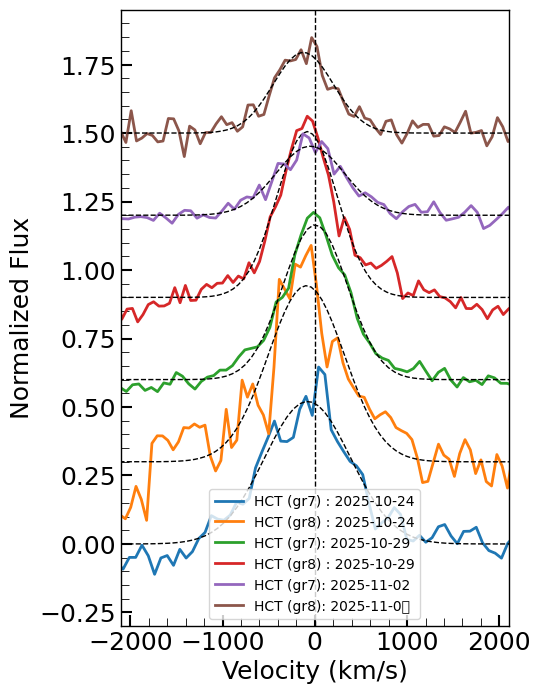

In [ ]:
hct_251024_gr7 = load_spec('../observational_data/spectra/2025-10-24_HCT_gr7_updated.csv', label='HCT (gr7) : 2025-10-24', z=-0.0015, ra=ra, dec=dec, convert_vac=True) # 
hct_251024 = load_spec('../observational_data/spectra/2025-10-24_HCT_gr8_updated.csv', label='HCT (gr8) : 2025-10-24', z=-0.0015, ra=ra, dec=dec, convert_vac=True) # 
hct_251029 = load_spec('../observational_data/spectra/2025-10-29_HCT_gr8_updated.csv', label='HCT (gr8) : 2025-10-29', z=-0.0015, ra=ra, dec=dec, convert_vac=True) # 
hct_251029_gr7 = load_spec('../observational_data/spectra/2025-10-29_HCT_gr7_updated.csv', label='HCT (gr7): 2025-10-29', z=-0.0015, ra=ra, dec=dec, convert_vac=True) # 
hct_251102_gr7 = load_spec( '../observational_data/spectra/2025-11-02_HCT_gr7_updated.csv', label='HCT (gr7): 2025-11-02', z=-0.0015, ra=ra, dec=dec, convert_vac=True) 
hct_251102_gr8 = load_spec( '../observational_data/spectra/2025-11-02_HCT_gr8_updated.csv', label='HCT (gr8): 2025-11-02', z=-0.0015, ra=ra, dec=dec, convert_vac=True) # 
hct_251106 = load_spec( '../observational_data/spectra/2025-11-06_HCT_gr7_updated.csv', label='HCT : 2025-11-06', z=-0.0015, ra=ra, dec=dec, convert_vac=True) # 


plt.figure(figsize=(5, 8))
continuum_wavelengths = [[6500, 6550], [6575, 6700]]
central_wav = 6564.61  # Central wavelength for H-alpha
const = 0
bounds=[(0, -1000, 0), (3, 200, 1000)]

hct_emission_fwhms, hct_emission_fwhms_uncs = [], []
hct_dates = []
for spec, snr in zip([hct_251024_gr7, hct_251024, hct_251029_gr7, hct_251029, hct_251102_gr7, hct_251102_gr8, hct_251106], 
                     [10, 10, 20, 20, 20, 20]
                    ):
    try:
        popt, pcov, velocity, flux_normalized, continuum_fit, wav_continuum, flux_continuum = spec.fit_single_emission_gaussian(degree=1, continuum_wavelengths=continuum_wavelengths, 
                                                                           central_wavelength=central_wav, initial_guess=[0.3, 0, 150], bounds=bounds)
        plt.plot(velocity, flux_normalized + const, label=spec.label, linewidth=2)
        plt.plot(velocity, single_gaussian(velocity, *popt) + const, linestyle='--', color='black')
        bootstrap_res = spec.bootstrap_velocity(mode='single', sn=snr,degree=1, continuum_wavelengths=continuum_wavelengths, 
                        central_wavelength=central_wav, initial_guess=[0.3, 0, 150], bounds=bounds, n_bootstrap=100)
        
    except RuntimeError:
        continue
    const += 0.3
    hct_emission_fwhms.append(bootstrap_res['sigma'][0]*2.3555)
    hct_emission_fwhms_uncs.append(bootstrap_res['sigma'][1]*2.3555)
    hct_dates.append(Time(spec.label.split(': ')[-1]).mjd)
    print(popt)

hct_emission_fwhms = np.array(hct_emission_fwhms)
hct_dates = np.array(hct_dates)
hct_res = 3e5/(6563/10)
hct_res_gr8 = 3e5/(6563/7)

plt.xlabel('Velocity (km/s)')
plt.ylabel('Normalized Flux')
plt.legend(fontsize=10)
plt.xlim(-2100, 2100)
plt.axvline(0, linestyle='--', color='black')
plt.minorticks_on()
#plt.savefig(r'../plots/at2025abao_plots/halpha_hct_plots.pdf', bbox_inches='tight')

[  0.64968347 103.1195307  308.38404826]
[  0.40060191 114.7528899  325.12761331]
[723.81029369 764.41246873]


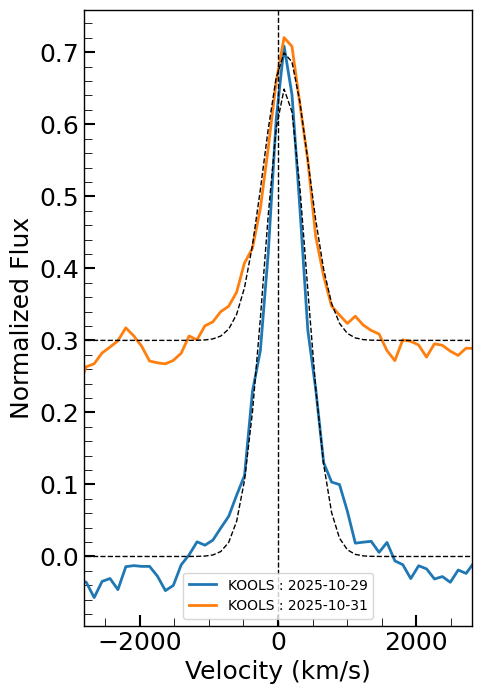

In [20]:
# Plot the best fit gaussian

kools_251031 = load_spec( '../observational_data/spectra/2025-10-31_KOOLS.csv', label='KOOLS : 2025-10-31', z=-0.0015, ra=ra, dec=dec) #
kools_251029 = load_spec( '../observational_data/spectra/2025-10-29_KOOLS.csv', label='KOOLS : 2025-10-29', z=-0.0015, ra=ra, dec=dec) #


plt.figure(figsize=(5, 8))
continuum_wavelengths = [[6500, 6550], [6575, 6700]]
central_wav = 6564.61  # Central wavelength for H-alpha
const = 0
bounds=[(0, -1000, 0), (3, 200, 1000)]

kools_emission_fwhms, kools_emission_fwhms_uncs = [], []
kools_dates = []
for spec, snr in zip([kools_251029, kools_251031], [50, 50]):
    try:
        popt, pcov, velocity, flux_normalized, continuum_fit, wav_continuum, flux_continuum = spec.fit_single_emission_gaussian(degree=1, continuum_wavelengths=continuum_wavelengths, 
                                                                           central_wavelength=central_wav, initial_guess=[0.3, 0, 150], bounds=bounds)
        plt.plot(velocity, flux_normalized + const, label=spec.label, linewidth=2)
        plt.plot(velocity, single_gaussian(velocity, *popt) + const, linestyle='--', color='black')
        bootstrap_res = spec.bootstrap_velocity(mode='single', sn=snr,degree=1, continuum_wavelengths=continuum_wavelengths, 
                        central_wavelength=central_wav, initial_guess=[0.3, 0, 150], bounds=bounds, n_bootstrap=100)
    except RuntimeError:
        continue
    const += 0.3
    kools_emission_fwhms.append(bootstrap_res['sigma'][0]*2.3555)
    kools_emission_fwhms_uncs.append(bootstrap_res['sigma'][1]*2.3555)
    kools_dates.append(Time(spec.label.split(': ')[-1]).mjd)
    print(popt)

kools_emission_fwhms = np.array(kools_emission_fwhms)
kools_dates = np.array(kools_dates)
kools_res = 3e5/(500)

print(kools_emission_fwhms)

plt.xlabel('Velocity (km/s)')
plt.ylabel('Normalized Flux')
plt.legend(fontsize=10)
plt.xlim(-2800, 2800)
plt.axvline(0, linestyle='--', color='black')
plt.minorticks_on()
# plt.savefig(r'../plots/at2025abao_plots/halpha_hct_plots.pdf', bbox_inches='tight')

[  0.50589364 -48.99904184  62.71201101  -0.88344727 -13.58549951
  23.90231504]
[147.14741951]


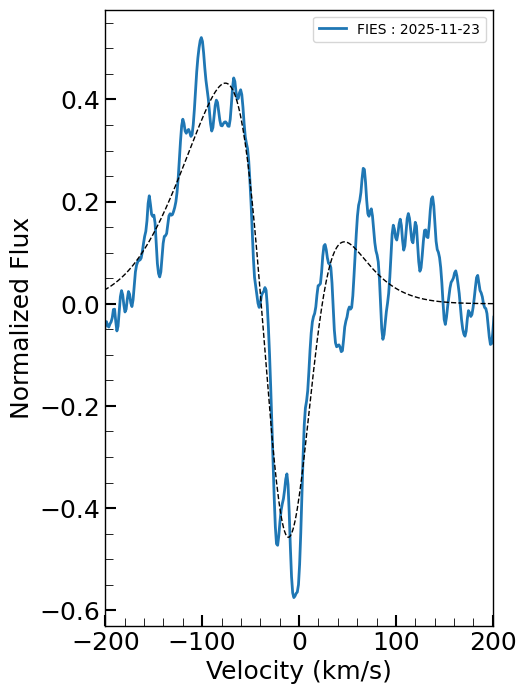

In [51]:
# Plot the best fit double gaussian
fies_251123 = load_spec( '../observational_data/spectra/2025-11-23T00:00:00_FIES2.csv', label='FIES : 2025-11-23', z=-0.0015, 
                         ra=ra, dec=dec, convert_vac=True, downsample=True, kernel_size=10) 


plt.figure(figsize=(5, 8))
continuum_wavelengths = [[6550, 6560], [6580, 6590]]
central_wav = 6564.61  # Central wavelength for H-alpha
const = 0
bounds=[(0, -200, 0, -3, -100, 0), (3, 200, 300, 0, 100, 100)]

fies_emission_fwhms, fies_emission_fwhms_uncs = [], []
fies_absorption_fwhms, fies_absorption_fwhms_uncs = [], []
fies_dates = []
for spec, snr in zip([fies_251123], [20]):
# for spec in [gmos_260126_r]:
    try:
        popt, pcov, velocity, flux_normalized, continuum_fit, wav_continuum, flux_continuum = spec.fit_double_emission_absorption_gaussian(degree=1, continuum_wavelengths=continuum_wavelengths, 
                                                                           central_wavelength=central_wav, initial_guess=[0.3, 0, 150, -1, 30, 40], bounds=bounds)
        plt.plot(velocity, flux_normalized + const, label=spec.label, linewidth=2)
        plt.plot(velocity, double_gaussian(velocity, *popt) + const, linestyle='--', color='black', zorder=10)
        bootstrap_res = spec.bootstrap_velocity(mode='double', sn=snr,degree=1, continuum_wavelengths=continuum_wavelengths, 
                        central_wavelength=central_wav, initial_guess=[0.3, 0, 150, -1, 30, 40], bounds=bounds, n_bootstrap=100)
    except RuntimeError:
        continue
    const += 0.5
    # fies_emission_fwhms.append(popt[2]*2.3555)
    # fies_absorption_fwhms.append(popt[5]*2.355)
    fies_emission_fwhms.append(bootstrap_res['sigma_emission'][0]*2.3555)
    fies_emission_fwhms_uncs.append(bootstrap_res['sigma_emission'][1]*2.3555)
    fies_absorption_fwhms.append(bootstrap_res['sigma_absorption'][0]*2.3555)
    fies_absorption_fwhms_uncs.append(bootstrap_res['sigma_absorption'][1]*2.3555)
    fies_dates.append(Time(spec.label.split(': ')[-1]).mjd)
    print(popt)
    
fies_emission_fwhms = np.array(fies_emission_fwhms)
fies_dates = np.array(fies_dates)
fies_res = 3e5/(25000)

print(fies_emission_fwhms)
# plt.plot(velocity, double_gaussian(velocity, 0.3, 0, 150, -1, 30, 40))
plt.xlabel('Velocity (km/s)')
plt.ylabel('Normalized Flux')
plt.legend(fontsize=10)
plt.xlim(-200, 200)

plt.minorticks_on()
# plt.savefig(r'../plots/at2025abao_plots/halpha_hct_plots.pdf', bbox_inches='tight')

[  3.         -26.01823929  73.14997338  -2.8071772  -17.94379213
  59.06717103]
[ 3.         -4.76055203 70.70811641 -2.56997965  7.2103804  53.75949996]


Text(0.5, 1.0, 'H$\\alpha$ GTC')

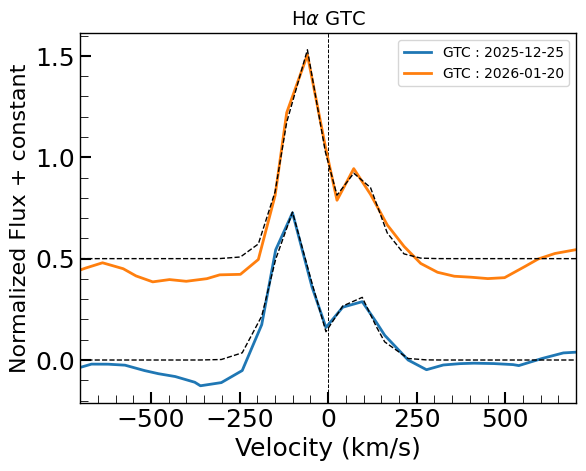

In [52]:
# Plot the best fit double gaussian
gtc_251225_r = load_spec( '../observational_data/spectra/2025-12-25T00:00:00_GTC_R.csv', label='GTC : 2025-12-25', z=-0.0015, 
                         ra=ra, dec=dec, convert_vac=False) 
gtc_260120_r = load_spec( '../observational_data/spectra/2026-01-20T00:00:00_GTC_R.csv', label='GTC : 2026-01-20', z=-0.0015, 
                         ra=ra, dec=dec, convert_vac=False) 



continuum_wavelengths = [[6500, 6550], [6575, 6600]]
central_wav = 6564.61  # Central wavelength for H-alpha
const = 0
bounds=[(0, -200, 0, -3, -100, 0), (3, 200, 300, 0, 100, 100)]

gtc_emission_fwhms, gtc_emission_fwhms_uncs = [], []
gtc_absorption_fwhms, gtc_absorption_fwhms_uncs = [], []
gtc_dates = []
for spec, snr in zip([gtc_251225_r, gtc_260120_r], [50, 50]):
# for spec in [gmos_260126_r]:
    try:
        popt, pcov, velocity, flux_normalized, continuum_fit, wav_continuum, flux_continuum = spec.fit_double_emission_absorption_gaussian(degree=1, continuum_wavelengths=continuum_wavelengths, 
                                                                           central_wavelength=central_wav, initial_guess=[0.3, 0, 150, -1, 30, 40], bounds=bounds)
        plt.plot(velocity, flux_normalized + const, label=spec.label, linewidth=2)
        plt.plot(velocity, double_gaussian(velocity, *popt) + const, linestyle='--', color='black', zorder=10)
        bootstrap_res = spec.bootstrap_velocity(mode='double', sn=snr,degree=1, continuum_wavelengths=continuum_wavelengths, 
                        central_wavelength=central_wav, initial_guess=[0.3, 0, 150, -1, 30, 40], bounds=bounds, n_bootstrap=100)
        # plt.plot(velocity, single_gaussian(velocity, *popt[:3]))
        # plt.plot(velocity, single_gaussian(velocity, *popt[3:]))
    except RuntimeError:
        continue
    const += 0.5
    gtc_emission_fwhms.append(bootstrap_res['sigma_emission'][0]*2.3555)
    gtc_emission_fwhms_uncs.append(bootstrap_res['sigma_emission'][1]*2.3555)
    gtc_absorption_fwhms.append(bootstrap_res['sigma_absorption'][0]*2.3555)
    gtc_absorption_fwhms_uncs.append(bootstrap_res['sigma_absorption'][1]*2.3555)
    gtc_dates.append(Time(spec.label.split(': ')[-1]).mjd)
    print(popt)

gtc_res = 3e5/(2500)
gtc_emission_fwhms = np.array(gtc_emission_fwhms)
gtc_absorption_fwhms = np.array(gtc_absorption_fwhms)

# plt.plot(velocity, double_gaussian(velocity, 0.3, 0, 150, -1, 30, 40))
plt.xlabel('Velocity (km/s)')
plt.ylabel('Normalized Flux + constant', size=16)
plt.axvline(0, color='black', linestyle='--', linewidth=0.7, zorder=-10)
plt.legend(fontsize=10)
plt.xlim(-700, 700)
plt.minorticks_on()
plt.title(r'H$\alpha$ GTC', size=14)
# plt.savefig(r'../plots/at2025abao_plots/halpha_gmos_plots.pdf', bbox_inches='tight')

[  0.29858117 -57.11531181 114.31979899  -0.71204184  -2.86158113
  31.07735074]
[ 2.75907948 -2.31504824 59.52912321 -3.          7.51005473 43.55752942]
[ 2.85202449 -1.40949007 61.1668911  -3.          9.55700443 41.65948508]
[ 2.91898872 -3.22095018 57.38370506 -3.          7.24947842 38.40266051]
[ 3.         -5.3445542  62.92908117 -2.63791465 15.44643749 33.37297102]
[  3.         -27.492234    54.40045649  -2.20994315   3.2988426
  24.41046414]


Text(0.5, 1.0, 'H$\\alpha$ GMOS')

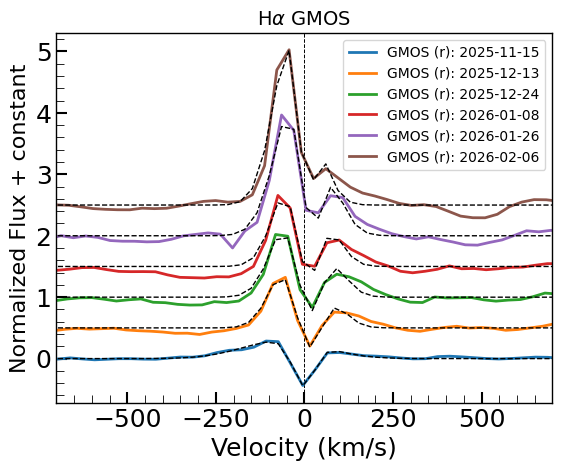

In [ ]:
# Plot the best fit double gaussian
continuum_wavelengths = [[6500, 6550], [6575, 6600]]
central_wav = 6564.61  # Central wavelength for H-alpha
const = 0
bounds=[(0, -200, 0, -3, -100, 0), (3, 200, 300, 0, 100, 100)]

gmos_emission_fwhms, gmos_emission_fwhms_uncs = [], []
gmos_absorption_fwhms, gmos_absorption_fwhms_uncs = [], []
gmos_dates = []
for spec, snr in zip([gmos_251115_r, gmos_251213_r, gmos_251224_r, gmos_260108_r, gmos_260126_r, gmos_260206_r],
                     [30, 30, 30, 30, 30, 30]
                    ):
# for spec in [gmos_260126_r]:
    try:
        popt, pcov, velocity, flux_normalized, continuum_fit, wav_continuum, flux_continuum = spec.fit_double_emission_absorption_gaussian(degree=1, continuum_wavelengths=continuum_wavelengths, 
                                                                           central_wavelength=central_wav, initial_guess=[0.3, 0, 150, -1, 30, 40], bounds=bounds)
        plt.plot(velocity, flux_normalized + const, label=spec.label, linewidth=2)
        plt.plot(velocity, double_gaussian(velocity, *popt) + const, linestyle='--', color='black', zorder=10)
        bootstrap_res = spec.bootstrap_velocity(mode='double', sn=snr,degree=1, continuum_wavelengths=continuum_wavelengths, 
                        central_wavelength=central_wav, initial_guess=[0.3, 0, 150, -1, 30, 40], bounds=bounds, n_bootstrap=100)

    except RuntimeError:
        continue
    const += 0.5
    # gmos_emission_fwhms.append(popt[2]*2.3555)
    # gmos_absorption_fwhms.append(popt[5]*2.355)

    gmos_emission_fwhms.append(bootstrap_res['sigma_emission'][0]*2.3555)
    gmos_emission_fwhms_uncs.append(bootstrap_res['sigma_emission'][1]*2.3555)
    gmos_absorption_fwhms.append(bootstrap_res['sigma_absorption'][0]*2.3555)
    gmos_absorption_fwhms_uncs.append(bootstrap_res['sigma_absorption'][1]*2.3555)
    
    gmos_dates.append(Time(spec.label.split(': ')[-1]).mjd)
    print(popt)

gmos_res = 3e5/(4396*2)
gmos_emission_fwhms = np.array(gmos_emission_fwhms)
gmos_absorption_fwhms = np.array(gmos_absorption_fwhms)

# plt.plot(velocity, double_gaussian(velocity, 0.3, 0, 150, -1, 30, 40))
plt.xlabel('Velocity (km/s)')
plt.ylabel('Normalized Flux + constant', size=16)
plt.axvline(0, color='black', linestyle='--', linewidth=0.7, zorder=-10)
plt.legend(fontsize=10)
plt.xlim(-700, 700)
plt.minorticks_on()
plt.title(r'H$\alpha$ GMOS', size=14)
# plt.savefig(r'../plots/at2025abao_plots/halpha_gmos_plots.pdf', bbox_inches='tight')

[  0.32546231 -58.96625951 198.86739943  -0.48142589  -5.64696446
  41.99215678]
[  0.28579614 -94.37590652 153.83572163  -0.57403865 -25.62839232
  34.75164556]
[ 1.40259401 -1.85024318 73.12521836 -1.63932    10.72339736 49.93307031]
[ 2.95452357  8.712367   72.77773278 -3.         15.6893643  58.63959798]
[ 3.         -5.6454512  67.00479416 -2.91383337  6.83577589 45.47376533]
[ 3.         -5.82631316 65.89690761 -2.4402958  14.32546675 39.98745369]


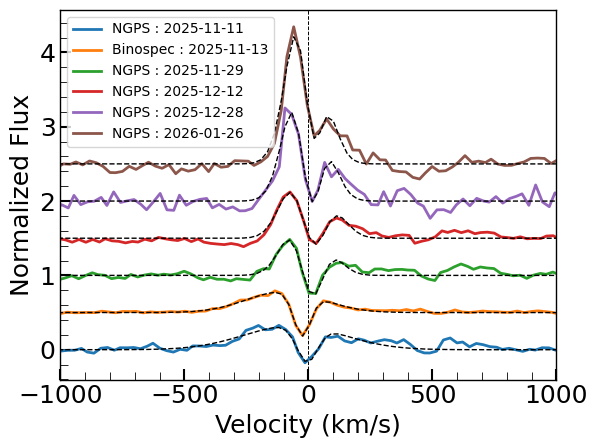

In [50]:
# Plot the best fit double gaussian
continuum_wavelengths = [[6500, 6550], [6575, 6600]]
central_wav = 6564.61  # Central wavelength for H-alpha
const = 0
bounds=[(0, -200, 0, -3, -100, 0), (3, 200, 300, 0, 100, 100)]

ngps_emission_fwhms, ngps_emission_fwhms_uncs = [], []
ngps_absorption_fwhms, ngps_absorption_fwhms_uncs = [], []
ngps_dates = []
for spec, snr in zip([ngps_251111, bspec_251113, ngps_251129, ngps_251212, ngps_251228, ngps_260126],
                     [30, 30, 30, 30, 30, 30]
                    ):
    try:
        popt, pcov, velocity, flux_normalized, continuum_fit, wav_continuum, flux_continuum = spec.fit_double_emission_absorption_gaussian(degree=1, continuum_wavelengths=continuum_wavelengths, 
                                                                           central_wavelength=central_wav, initial_guess=[0.3, 0, 150, -1, 30, 40], bounds=bounds)
        plt.plot(velocity, flux_normalized + const, label=spec.label, linewidth=2)
        plt.plot(velocity, double_gaussian(velocity, *popt) + const, linestyle='--', color='black')
        bootstrap_res = spec.bootstrap_velocity(mode='double', sn=snr,degree=1, continuum_wavelengths=continuum_wavelengths, 
                        central_wavelength=central_wav, initial_guess=[0.3, 0, 150, -1, 30, 40], bounds=bounds, n_bootstrap=100)
    except RuntimeError:
        continue
    const += 0.5
    # ngps_emission_fwhms.append(popt[2]*2.3555)
    # ngps_absorption_fwhms.append(popt[5]*2.355)

    ngps_emission_fwhms.append(bootstrap_res['sigma_emission'][0]*2.3555)
    ngps_emission_fwhms_uncs.append(bootstrap_res['sigma_emission'][1]*2.3555)
    ngps_absorption_fwhms.append(bootstrap_res['sigma_absorption'][0]*2.3555)
    ngps_absorption_fwhms_uncs.append(bootstrap_res['sigma_absorption'][1]*2.3555)
    
    ngps_dates.append(Time(spec.label.split(': ')[-1]).mjd)
    print(popt)

ngps_res = 3e5/(6600)
ngps_emission_fwhms = np.array(ngps_emission_fwhms)
ngps_absorption_fwhms = np.array(ngps_absorption_fwhms)

# plt.plot(velocity, double_gaussian(velocity, 0.3, 0, 150, -1, 30, 40))
plt.xlabel('Velocity (km/s)')
plt.ylabel('Normalized Flux')
plt.legend(fontsize=10)
plt.axvline(0, color='black', linestyle='--', linewidth=0.7, zorder=-10)
plt.xlim(-1000, 1000)
plt.minorticks_on()

# plt.savefig(r'../plots/at2025abao_plots/halpha_ngps_plots.pdf', bbox_inches='tight')

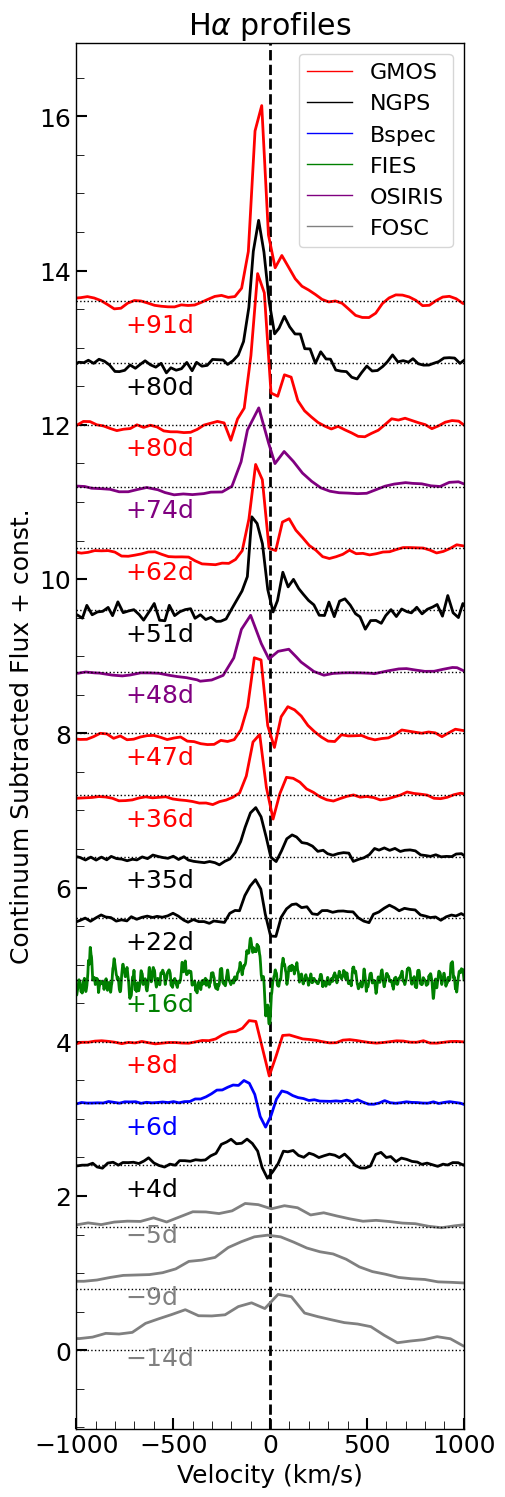

In [15]:
# Make side by side plots
plt.figure(figsize=(5, 18))
continuum_wavelengths = [[6300, 6500], [6700, 6800]]
central_wav = 6564.6  # Central wavelength for H-alpha
const = 0
jd_ref = 2460986.5
for spec in [hct_251024_gr7, hct_251029_gr7, hct_251102_gr7,
    ngps_251111, bspec_251113, gmos_251115_r, fies_251123, ngps_251129, ngps_251212, gmos_251213_r, gmos_251224_r, gtc_251225_r,
             ngps_251228, 
             gmos_260108_r, gtc_260120_r, gmos_260126_r, ngps_260126, gmos_260206_r]:
    wav_norm, flux_norm, _, _, _ = spec.continuum_normalize(
        degree=1, continuum_wavelengths=continuum_wavelengths,
    )
    velocities = ((wav_norm - central_wav) / central_wav) * 3e5  # Convert to km/s
    if 'GMOS' in spec.label:
        color='red'
    elif 'NGPS' in spec.label:
        color='black'
    elif 'Binospec' in spec.label:
        color='blue'
    elif 'FIES' in spec.label:
        color='green'
    elif 'GTC' in spec.label:
        color='purple'
    elif 'HCT' in spec.label:
        color='gray'
    plt.plot(velocities, flux_norm - 1 + const,
             alpha=1, linewidth=2, color=color)
    plt.axhline(const, linestyle=':', color='black')

    phase = int(spec.jd - jd_ref)
    sign = '+'
    if phase < 0:
        sign = '-'
    doffset = 0.4
    if 'HCT' in spec.label:
        doffset = 0.2
    plt.text(-750, const - doffset,  f'${sign}{np.abs(phase)}$d', size=18, color=color)
    const += 0.8

plt.plot(0,0,color='red', label='GMOS')
plt.plot(0,0,color='black', label='NGPS')
plt.plot(0,0,color='blue', label='Bspec')
plt.plot(0,0,color='green', label='FIES')
plt.plot(0,0,color='purple', label='OSIRIS')
plt.plot(0,0,color='gray', label='FOSC')
# plt.legend(fontsize=12)
plt.minorticks_on()
plt.xlim(-1000, 1000)
plt.axvline(0, color='black', linestyle='--', linewidth=2, zorder=-10)
# plt.axvline(-20, color='black', linestyle=':', linewidth=2, zorder=-10)
plt.xlabel('Velocity (km/s)')
plt.ylabel('Continuum Subtracted Flux + const.')
plt.title(r'H$\alpha$ profiles')
plt.legend(fontsize=16)
# plt.savefig(r'../plots/at2025abao_plots/halpha_profiles.pdf', bbox_inches='tight')

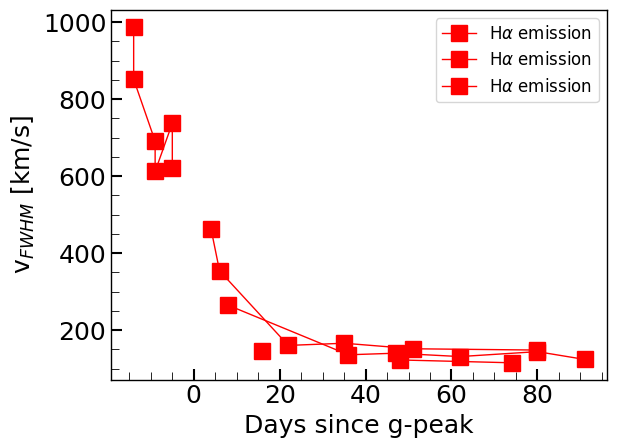

In [25]:
gpeak = 60986
plt.plot(np.array(gmos_dates) - gpeak, np.sqrt(gmos_emission_fwhms**2 - gmos_res**2), marker='s', markersize=12, color='red')


plt.plot(np.array(ngps_dates) - gpeak, np.sqrt(ngps_emission_fwhms**2 - ngps_res**2), marker='s', markersize=12, color='red')

plt.plot(np.array(hct_dates) - gpeak, np.sqrt(hct_emission_fwhms**2 - hct_res**2), marker='s', markersize=12, color='red', label=r'H$\alpha$ emission')

plt.plot(np.array(fies_dates) - gpeak, np.sqrt(fies_emission_fwhms**2 - fies_res**2), marker='s', markersize=12, color='red', label=r'H$\alpha$ emission')

plt.plot(np.array(gtc_dates) - gpeak, np.sqrt(gtc_emission_fwhms**2 - gtc_res**2), marker='s', markersize=12, color='red', label=r'H$\alpha$ emission')


plt.xlabel('Days since g-peak', size=18)
plt.ylabel(r'v$_{FWHM}$ [km/s]', size=18)
plt.legend(fontsize=12)

plt.minorticks_on()
#plt.savefig(r'../plots/at2025abao_plots/fwhm_evolution.pdf', bbox_inches='tight')

In [26]:
from scipy.integrate import solve_ivp

In [27]:
Mej = 0.1*2e33          # initial ejecta mass
vej = 1.0e8        # initial velocity (cm/s or any consistent units)

rho0 = 7e-12       # CSM density normalization
r0 = 2e14          # launch radius

A = 7e18 #4 * np.pi * rho0 * r0**2

# -------------------------
# ODE system
# y = [r, M, v]
# -------------------------
def rhs(t, y):
    r, M, v = y

    drdt = v
    dMdt = A * v

    dvdt = (Edot / (M * v)) - (A / M) * v**2

    return [drdt, dMdt, dvdt]


y0 = [r0, Mej, vej]

In [28]:
def plot_opt_spec(spec, color, offset = 0, use_convolve: bool=True, additional_scale=1):
    scale = np.nanmedian(spec['flam'])/ additional_scale
    alpha = 1
    if use_convolve:
        alpha=0.1
    ax.plot(spec['wav'], spec['flam']/scale + offset, alpha=alpha, color=color)

    if use_convolve:
        convol_ind = 10
        box = Box1DKernel(8)
        ax.plot(spec['wav'][convol_ind:-1*convol_ind], convolve(spec['flam'], box)[convol_ind:-1*convol_ind]/scale + offset, color=color)
    return ax


def get_telluric_masked(spec):
    spec = spec[~((spec['wav']>0.755) & (spec['wav']<0.766)) & ~((spec['wav']>0.685) & (spec['wav']<0.692))]
    return spec

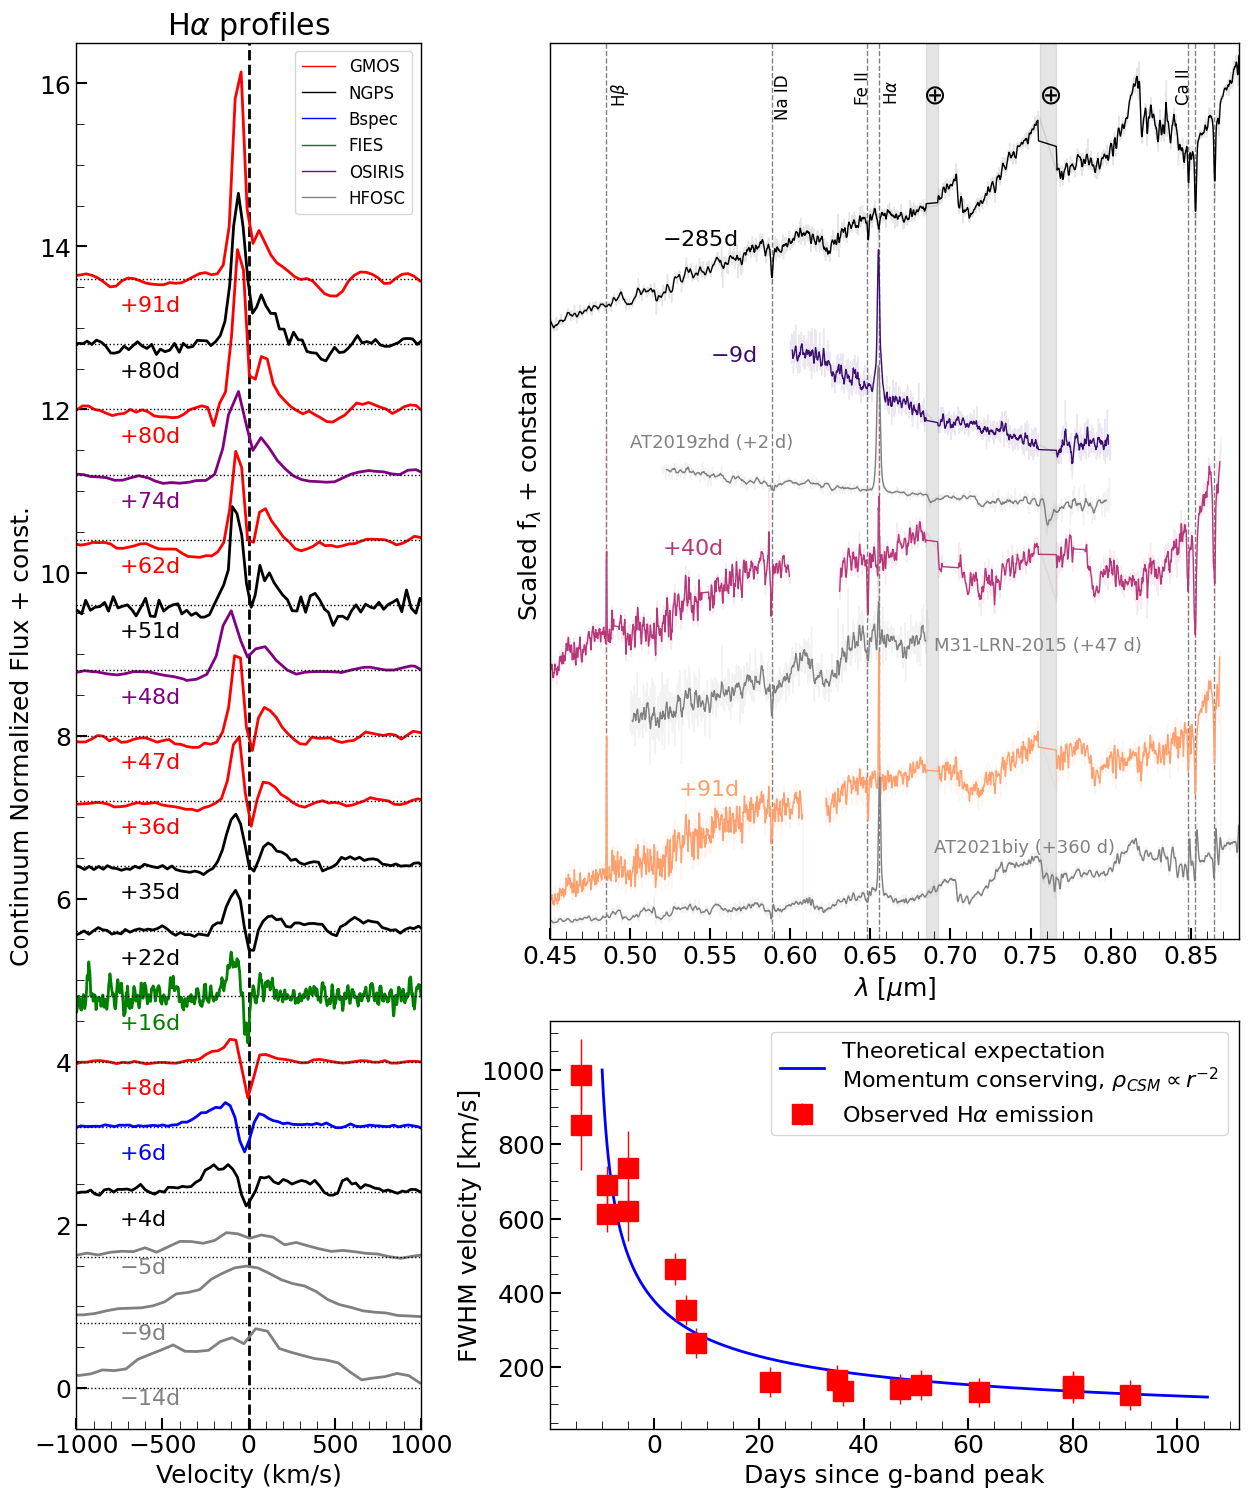

In [37]:
fig = plt.figure(figsize=(15, 18))

gs = GridSpec(nrows=3, ncols=2, width_ratios=[1, 2], wspace=0.25)

ax = fig.add_subplot(gs[0:2,1])

cmap = matplotlib.colormaps['magma']
total_specs = 10

gemini_color  = 'red'
bspec_color = 'red'
ngps_color = 'orange'
lowres_color = 'red'

spec = pd.read_csv('../observational_data/spectra/2025-01-26T06:26:07_LRIS_42544.csv')
spec['wav'] *= 1e-4
spec = get_telluric_masked(spec)
ax = plot_opt_spec(spec=spec, color=cmap(0/10), offset = 0, additional_scale=6)

spec = pd.read_csv('../observational_data/spectra/2025-10-29_HCT_gr8_updated.csv')
spec['wav'] *= 1e-4
spec = get_telluric_masked(spec)
spec = spec[(spec['wav']>0.6) & (spec['wav']<0.8)]
ax = plot_opt_spec(spec=spec, color=cmap(2/10), offset = -9, additional_scale=7)

spec = pd.read_csv('../observational_data/spectra/2025-12-13T05:58:33_GMOS_49283.csv')
spec['wav'] *= 1e-4
spec = get_telluric_masked(spec)
spec = spec[~((spec['wav']>0.695) &(spec['wav']<0.705)) & (spec['wav']>0.63) & ~((spec['wav']>0.777) &(spec['wav']<0.784)) & (spec['wav']<0.869)]
ax = plot_opt_spec(spec=spec, color=cmap(5/10), offset = -15, use_convolve=True, additional_scale=8)

spec = pd.read_csv('../observational_data/spectra/2025-12-17T05:02:24_GMOS_49501.csv')
spec['wav'] *= 1e-4
spec = get_telluric_masked(spec)
spec = spec[~((spec['wav']>0.490) &(spec['wav']<0.493)) & ~((spec['wav']>0.545) &(spec['wav']<0.549)) & (spec['wav']<0.6)]
ax = plot_opt_spec(spec=spec, color=cmap(5/10), offset = -13, use_convolve=True, additional_scale=4)

spec = pd.read_csv('../observational_data/spectra/2026-02-05T00:00:00_GMOS_50460.csv')
spec['wav'] *= 1e-4
spec = get_telluric_masked(spec)
ax = plot_opt_spec(spec=spec, color=cmap(8/10),  offset = -20, use_convolve=True, additional_scale=3)

spec = pd.read_csv('../observational_data/spectra/2026-02-06T05:16:48_GMOS_50459.csv')
spec['wav'] *= 1e-4
spec = get_telluric_masked(spec)
ax = plot_opt_spec(spec=spec, color=cmap(8/10),  offset = -19, use_convolve=True, additional_scale=5)



m31_1 = ascii.read('../observational_data/comparison_spectra/iPTF15t_2015-03-10_MDM-2.4_OSMOS_iPTF.ascii')
m31_1 = m31_1[(m31_1['col1']>5000) & ~((m31_1['col1']>7500) & (m31_1['col1']<7800)) & (m31_1['col1']<8500)]
m31_1['wav'] = m31_1['col1']*1e-4
m31_1['flam'] = m31_1['col2']*1e-4
ax = plot_opt_spec(spec=m31_1, color='gray',  offset = -13, use_convolve=True, additional_scale=2)

at2021blu_1 = ascii.read('../observational_data/comparison_spectra/ZTF21aancgbm_Keck_LRIS_2022-02-03.dat')
at2021blu_1['wav'] = at2021blu_1['Wav(Angstrom)']*1e-4 / (1+0.003)
at2021blu_1['flam'] = at2021blu_1['Flux density (a.d.u.)']
ax = plot_opt_spec(spec=at2021blu_1, color='gray',  offset = -20, use_convolve=True, additional_scale=2)

at2019zhd_1 = ascii.read('../observational_data/comparison_spectra/tns_2019zhd_2458893.9_Other_Other.dat')
at2019zhd_1 = at2019zhd_1[at2019zhd_1['col1']>5200]
at2019zhd_1['wav'] = at2019zhd_1['col1']*1e-4
at2019zhd_1['flam'] = at2019zhd_1['col2']
ax = plot_opt_spec(spec=at2019zhd_1, color='gray',  offset = -6, use_convolve=True, additional_scale=1.5)

ax.set_xlim(0.45, 0.88)
ymn, ymx = ax.set_ylim(-20, 11)
ax.fill_betweenx(x1=0.756, x2=0.766, y=[ymn, ymx], color='gray', alpha=0.2)
ax.fill_betweenx(x1=0.685, x2=0.692, y=[ymn, ymx], color='gray', alpha=0.2)
plt.minorticks_on()
# ax.set_xscale('log')
ax.set_yticks([])
ax.set_xlabel(r'$\lambda$ [$\mu$m]', size=18)
ax.set_ylabel(r'Scaled f$_{\lambda}$ + constant', size=18)

ax.axvline(0.6563 * (1-0.0018), color='gray', linestyle='--', zorder = 0)
ax.axvline(0.5896 * (1-0.0018), color='gray', linestyle='--', zorder = 0)
ax.axvline(0.4861 * (1-0.0018), color='gray', linestyle='--', zorder = 0)
ax.axvline(0.6493 * (1-0.0018), color='gray', linestyle='--', zorder = 0)
ax.axvline(0.8498 * (1-0.0018), color='gray', linestyle='--', zorder = 0)
ax.axvline(0.8542 * (1-0.0018), color='gray', linestyle='--', zorder = 0)
ax.axvline(0.8662 * (1-0.0018), color='gray', linestyle='--', zorder = 0)

ax.text(0.658, 9, r'H$\alpha$', size=12, color='black', rotation=90)
ax.text(0.84, 9, r'Ca II', size=12, color='black', rotation=90)
ax.text(0.64, 9, r'Fe II', size=12, color='black', rotation=90)
ax.text(0.59, 8.5, r'Na ID', size=12, color='black', rotation=90)
ax.text(0.487, 9, r'H$\beta$', size=12, color='black', rotation=90)
ax.text(0.755, 9, r'$\oplus$', size=20, color='black', rotation=90)
ax.text(0.683, 9, r'$\oplus$', size=20, color='black', rotation=90)

mjd0 = 60986
ax.text(0.52, 4, f"${int(Time('2025-01-26').mjd - mjd0)}$" +'d', color=cmap(0/10), size=16)
ax.text(0.55, 0, f"${int(Time('2025-10-29').mjd - mjd0)}$" +'d', color=cmap(2/10), size=16)
ax.text(0.52, -6.7, f"$+{int(Time('2025-12-17').mjd - mjd0)}$" +'d', color=cmap(5/10), size=16)
ax.text(0.53, -15, f"$+{int(Time('2026-02-06').mjd - mjd0)}$" +'d', color=cmap(8/10), size=16)

ax.text(0.5, -3, "AT2019zhd (+2 d)", color='gray', size=13)
ax.text(0.69, -10, "M31-LRN-2015 (+47 d)", color='gray', size=13)
ax.text(0.69, -17, "AT2021biy (+360 d)", color='gray', size=13)


# Make side by side plots
ax = fig.add_subplot(gs[:,0])
continuum_wavelengths = [[6300, 6500], [6700, 6800]]
central_wav = 6564.6  # Central wavelength for H-alpha
const = 0
jd_ref = 2460986.5
for spec in [hct_251024_gr7, hct_251029_gr7, hct_251102_gr7,
    ngps_251111, bspec_251113, gmos_251115_r, fies_251123, ngps_251129, ngps_251212, gmos_251213_r, gmos_251224_r, gtc_251225_r,
             ngps_251228, 
             gmos_260108_r, gtc_260120_r, gmos_260126_r, ngps_260126, gmos_260206_r]:
    wav_norm, flux_norm, _, _, _ = spec.continuum_normalize(
        degree=1, continuum_wavelengths=continuum_wavelengths,
    )
    velocities = ((wav_norm - central_wav) / central_wav) * 3e5  # Convert to km/s
    if 'GMOS' in spec.label:
        color='red'
    elif 'NGPS' in spec.label:
        color='black'
    elif 'Binospec' in spec.label:
        color='blue'
    elif 'FIES' in spec.label:
        color='green'
    elif 'GTC' in spec.label:
        color='purple'
    elif 'HCT' in spec.label:
        color='gray'
    ax.plot(velocities, flux_norm - 1 + const,
             alpha=1, linewidth=2, color=color)
    ax.axhline(const, linestyle=':', color='black')

    phase = int(spec.jd - jd_ref)
    sign = '+'
    if phase < 0:
        sign = '-'
    doffset = 0.4
    if 'HCT' in spec.label:
        doffset = 0.2
    ax.text(-750, const - doffset,  f'${sign}{np.abs(phase)}$d', size=16, color=color)
    const += 0.8

ax.plot(0,0,color='red', label='GMOS')
ax.plot(0,0,color='black', label='NGPS')
ax.plot(0,0,color='blue', label='Bspec')
ax.plot(0,0,color='green', label='FIES')
ax.plot(0,0,color='purple', label='OSIRIS')
ax.plot(0,0,color='gray', label='HFOSC')
# plt.legend(fontsize=12)
ax.minorticks_on()
ax.set_xlim(-1000, 1000)
ax.set_ylim(-0.5, 16.5)
ax.axvline(0, color='black', linestyle='--', linewidth=2, zorder=-10)
# plt.axvline(-20, color='black', linestyle=':', linewidth=2, zorder=-10)
ax.set_xlabel('Velocity (km/s)')
ax.set_ylabel('Continuum Normalized Flux + const.')
ax.set_title(r'H$\alpha$ profiles')
ax.legend(fontsize=12)


ax = fig.add_subplot(gs[2,1])

t_span = (0, 1e7)
Edot = 0 
t_eval = np.linspace(*t_span, 1000)
sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='RK45')
r, M, v_eval = sol.y

# Plot
ax.plot(t_eval/86400 - 10, v_eval/1e5, label='Theoretical expectation \n' + r'Momentum conserving, $\rho_{CSM} \propto r^{-2}$', color='blue', linewidth=2)

gpeak = 60986
ax.errorbar(np.array(gmos_dates) - gpeak, np.sqrt(gmos_emission_fwhms**2 - gmos_res**2), 
            np.max([gmos_emission_fwhms_uncs, [40]*len(gmos_emission_fwhms_uncs)], axis=0), marker='s', markersize=14, color='red', 
            linestyle='')
# plt.plot(gmos_dates, np.sqrt(gmos_absorption_fwhms**2 - gmos_res**2), marker='o', markersize=12, color='blue', 
#          label=r'H$\alpha$ absorption')

ax.errorbar(np.array(ngps_dates) - gpeak, np.sqrt(ngps_emission_fwhms**2 - ngps_res**2), 
            np.max([ngps_emission_fwhms_uncs, [40]*len(ngps_emission_fwhms_uncs)], axis=0),
        marker='s', markersize=14, color='red', linestyle='')
#plt.plot(ngps_dates, np.sqrt(ngps_absorption_fwhms**2 - ngps_res**2), marker='o', markersize=12, color='blue')

ax.errorbar(np.array(hct_dates) - gpeak, np.sqrt(hct_emission_fwhms**2 - hct_res**2), hct_emission_fwhms_uncs, 
            marker='s', markersize=14, color='red', 
        label=r'Observed H$\alpha$ emission', linestyle='')


ax.set_xlabel("Days since g-band peak")
ax.set_ylabel("FWHM velocity [km/s]", labelpad=0)
ax.legend(fontsize=16)
ax.minorticks_on()

# plt.savefig(r'../plots/at2025abao_plots/spectra_combined_figure.pdf', bbox_inches='tight')

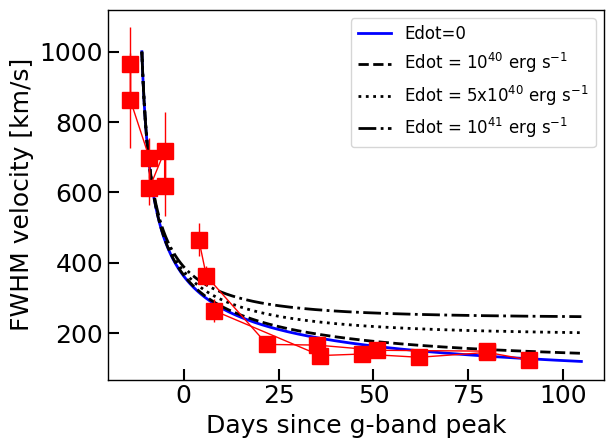

In [21]:
plt.figure()

t_span = (0, 1e7)

Edot = 0 
t_eval = np.linspace(*t_span, 1000)
sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='RK45')
r, M, v = sol.y
t = sol.t
plt.plot(t/86400 - 11, v*1e-5, color='blue', linestyle='-', linewidth=2, label='Edot=0')

Edot = 1e40 
t_eval = np.linspace(*t_span, 1000)
sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='RK45')
r, M, v = sol.y
t = sol.t
plt.plot(t/86400 - 11, v*1e-5, color='black', linestyle='--', linewidth=2, label=r'Edot = 10$^{40}$ erg s$^{-1}$')

Edot = 5e40 
t_eval = np.linspace(*t_span, 1000)
sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='RK45')
r, M, v = sol.y
t = sol.t
plt.plot(t/86400 - 11, v*1e-5, color='black', linestyle=':', linewidth=2, label=r'Edot = 5x10$^{40}$ erg s$^{-1}$')

Edot = 1e41 
t_eval = np.linspace(*t_span, 1000)
sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='RK45')
r, M, v = sol.y
t = sol.t
plt.plot(t/86400 - 11, v*1e-5, color='black', linestyle='-.', linewidth=2, label=r'Edot = 10$^{41}$ erg s$^{-1}$')

gpeak = 60986
plt.errorbar(np.array(gmos_dates) - gpeak, np.sqrt(gmos_emission_fwhms**2 - gmos_res**2), gmos_emission_fwhms_uncs, marker='s', markersize=12, color='red')

plt.errorbar(np.array(ngps_dates) - gpeak, np.sqrt(ngps_emission_fwhms**2 - ngps_res**2), ngps_emission_fwhms_uncs, marker='s', markersize=12, color='red')

plt.errorbar(np.array(hct_dates) - gpeak, np.sqrt(hct_emission_fwhms**2 - hct_res**2), hct_emission_fwhms_uncs, marker='s', markersize=12, color='red')


plt.xlabel("Days since g-band peak")
plt.ylabel("FWHM velocity [km/s]")

plt.legend(fontsize=12)
# plt.savefig(r'../plots/at2025abao_plots/velocity_evolution_energy_deposition.pdf', bbox_inches='tight')